#  Analyse des commandes d'un restaurant
Nous avons deux fichiers plats à analyser **order.csv** et **men_item.csv**. Nous avons besoin d'analyser les 2 pour répondre aux questions suivantes:
1. Quels sont les articles qui génèrent le plus et le moins de revenus ?
2. Quelles sont les périodes où les revenus sont les plus élevés et les plus faibles ?

# Importation de la base de données des commandes

In [1]:
# Importation de la librairie Pandans
import pandas as pd

# Chargement et profilage des données
commande_df = pd.read_csv("../data/raw/order_details.csv")

commande_df.head()

,order_details_id,order_id,order_date,order_time,item_id
0,1,1,1/1/23,11:38:36 AM,109.0
1,2,2,1/1/23,11:57:40 AM,108.0
2,3,2,1/1/23,11:57:40 AM,124.0
3,4,2,1/1/23,11:57:40 AM,117.0
4,5,2,1/1/23,11:57:40 AM,129.0


In [2]:
commande_df.tail()

,order_details_id,order_id,order_date,order_time,item_id
12229,12230,5369,3/31/23,10:05:04 PM,109.0
12230,12231,5369,3/31/23,10:05:04 PM,129.0
12231,12232,5369,3/31/23,10:05:04 PM,120.0
12232,12233,5369,3/31/23,10:05:04 PM,122.0
12233,12234,5370,3/31/23,10:15:48 PM,122.0


## Remarques 1
Nous constatons que le fichier comporte des commandes de **3 mois** allant du **1/1/2023** au **31/3/2023**

In [3]:
# Nous allons examiner les données données avec la méthode info() pour identifier les types des colonnes et dectecter les valeurs manquantes
commande_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12234 entries, 0 to 12233
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  12234 non-null  int64  
 1   order_id          12234 non-null  int64  
 2   order_date        12234 non-null  object 
 3   order_time        12234 non-null  object 
 4   item_id           12097 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 478.0+ KB


## Remarque 2
- Les données présentent **12234** articles commandées
- La colonne item_id comporte des valeurs manquantes environ **137**
- Le type de la colonne **order_time** est incorect, ce qui veux dire les données ont surement mal été chargées 

In [4]:
# Reprenons le chargement des données en précisant le paramètre parse-date
commande_df_correct = pd.read_csv("../data/raw/order_details.csv", parse_dates=["order_date", "order_time"])
commande_df_correct.info()

C:\Users\almam\AppData\Local\Temp\ipykernel_42488\4259938695.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  commande_df_correct = pd.read_csv("../data/raw/order_details.csv", parse_dates=["order_date", "order_time"])
C:\Users\almam\AppData\Local\Temp\ipykernel_42488\4259938695.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  commande_df_correct = pd.read_csv("../data/raw/order_details.csv", parse_dates=["order_date", "order_time"])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12234 entries, 0 to 12233
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  12234 non-null  int64         
 1   order_id          12234 non-null  int64         
 2   order_date        12234 non-null  datetime64[ns]
 3   order_time        12234 non-null  datetime64[ns]
 4   item_id           12097 non-null  float64       
dtypes: datetime64[ns](2), float64(1), int64(2)
memory usage: 478.0 KB


In [5]:
commande_df_correct.head()

,order_details_id,order_id,order_date,order_time,item_id
0,1,1,2023-01-01,2026-04-10 11:38:36,109.0
1,2,2,2023-01-01,2026-04-10 11:57:40,108.0
2,3,2,2023-01-01,2026-04-10 11:57:40,124.0
3,4,2,2023-01-01,2026-04-10 11:57:40,117.0
4,5,2,2023-01-01,2026-04-10 11:57:40,129.0


*Maintemant la date et l'heure sont de type datetime*

# Netoyage des données

In [6]:
# Traitment des valeurs manquantes en les supprimant
commande_df_correct.dropna(inplace=True)

In [7]:
commande_df_correct.isna().sum()

order_details_id    0
order_id            0
order_date          0
order_time          0
item_id             0
dtype: int64

In [8]:
commande_df_correct.count()

order_details_id    12097
order_id            12097
order_date          12097
order_time          12097
item_id             12097
dtype: int64

# Jointure 
*Jointure entre la table des commmandes **order_items.csv** et celle des articles **menu_items.csv***

In [9]:
menu_df = pd.read_csv("../data/raw/menu_items.csv")
menu_df.head()

,menu_item_id,item_name,category,price
0,101,Hamburger,American,12.95
1,102,Cheeseburger,American,13.95
2,103,Hot Dog,American,9.00
3,104,Veggie Burger,American,10.50
4,105,Mac & Cheese,American,7.00


In [10]:
commande_df_correct = commande_df_correct.merge(menu_df, how="left", left_on="item_id", right_on="menu_item_id").drop("menu_item_id", axis=1)
commande_df_correct.head()

,order_details_id,order_id,order_date,order_time,item_id,item_name,category,price
0,1,1,2023-01-01,2026-04-10 11:38:36,109.0,Korean Beef Bowl,Asian,17.95
1,2,2,2023-01-01,2026-04-10 11:57:40,108.0,Tofu Pad Thai,Asian,14.50
2,3,2,2023-01-01,2026-04-10 11:57:40,124.0,Spaghetti,Italian,14.50
3,4,2,2023-01-01,2026-04-10 11:57:40,117.0,Chicken Burrito,Mexican,12.95
4,5,2,2023-01-01,2026-04-10 11:57:40,129.0,Mushroom Ravioli,Italian,15.50


# Ajoiuter la colonne des taxes et celles du chiffre d'affaires

In [11]:
commande_df_correct["tax"] = (commande_df_correct["price"] * .08).round(2)
commande_df_correct["total_revenu"] = commande_df_correct["price"] + commande_df_correct["tax"]
commande_df_correct.head()

,order_details_id,order_id,order_date,order_time,item_id,item_name,category,price,tax,total_revenu
0,1,1,2023-01-01,2026-04-10 11:38:36,109.0,Korean Beef Bowl,Asian,17.95,1.44,19.39
1,2,2,2023-01-01,2026-04-10 11:57:40,108.0,Tofu Pad Thai,Asian,14.50,1.16,15.66
2,3,2,2023-01-01,2026-04-10 11:57:40,124.0,Spaghetti,Italian,14.50,1.16,15.66
3,4,2,2023-01-01,2026-04-10 11:57:40,117.0,Chicken Burrito,Mexican,12.95,1.04,13.99
4,5,2,2023-01-01,2026-04-10 11:57:40,129.0,Mushroom Ravioli,Italian,15.50,1.24,16.74


# Analyse descriptive de nos données

In [12]:
commande_df_correct.describe()

,order_details_id,order_id,order_date,order_time,item_id,price,tax,total_revenu
count,12097.000000,12097.000000,12097,12097,12097.000000,12097.000000,12097.000000,12097.000000
mean,6118.950897,2692.569149,2023-02-14 11:17:33.781929216,2026-04-10 16:22:19.455071488,115.202282,13.161767,1.055128,14.216895
min,1.000000,1.000000,2023-01-01 00:00:00,2026-04-10 10:50:46,101.000000,5.000000,0.400000,5.400000
25%,3064.000000,1353.000000,2023-01-23 00:00:00,2026-04-10 13:26:19,107.000000,10.500000,0.840000,11.340000
50%,6119.000000,2711.000000,2023-02-14 00:00:00,2026-04-10 16:30:20,114.000000,13.950000,1.120000,15.070000
75%,9175.000000,4020.000000,2023-03-09 00:00:00,2026-04-10 18:52:11,123.000000,16.500000,1.320000,17.820000
max,12234.000000,5370.000000,2023-03-31 00:00:00,2026-04-10 23:05:24,132.000000,19.950000,1.600000,21.550000
std,3531.337208,1545.826452,NaN,NaN,9.387580,3.986392,0.320078,4.306466


# Remarque 3
- Le maximum de notre order_details_id est de 12234, ce qui pourrait correspondre au nombre d'article commandés, mais ce n'est pas le cas ici
- Le prix le plus bas est de *$5* et le plus élévé est de **$19.95** avec un prix moyen de **$13.16** et une médian de **$13.95**. Les articles a faibles prix tirent peu la moyenne vers le bas.
- 

# Annalyse des meilleurs et le pire de ventes

In [13]:
# Grouper ou faire des agregations par le nom d'article

(commande_df_correct
.groupby(["item_name"])
.agg({"total_revenu": "sum"})
.sort_values(by="total_revenu")
)

,total_revenu
item_name,
Chicken Tacos,1587.93
Potstickers,1992.60
Chips & Guacamole,2303.64
Hot Dog,2498.04
Cheese Quesadillas,2642.22
Veggie Burger,2698.92
Steak Tacos,3224.98
Edamame,3348.00
Cheese Lasagna,3465.18


In [14]:
(commande_df_correct
.groupby(["item_name"])
.agg({"total_revenu": "sum"})
.sort_values(by="total_revenu")
)

,total_revenu
item_name,
Chicken Tacos,1587.93
Potstickers,1992.60
Chips & Guacamole,2303.64
Hot Dog,2498.04
Cheese Quesadillas,2642.22
Veggie Burger,2698.92
Steak Tacos,3224.98
Edamame,3348.00
Cheese Lasagna,3465.18


Cette analyse montre que **Korean Beef Bowl** est le plat le plus vendu ave **11 401$** de chiffre d'affaire suivi de **Spaghettie & Meatballs** etc...

Mais en faisant focus sur la partie ou le restaurant doit ameliorer est au niveau **chicken Tacos, PotStickers, Chips & Guancamole, etc** avec un chiffre d'affaire inferieur a **3 000$**

Mais cette analyse est toujours difficile a lire, maintenant essayons de resoudre cela en visualisant ce resultat

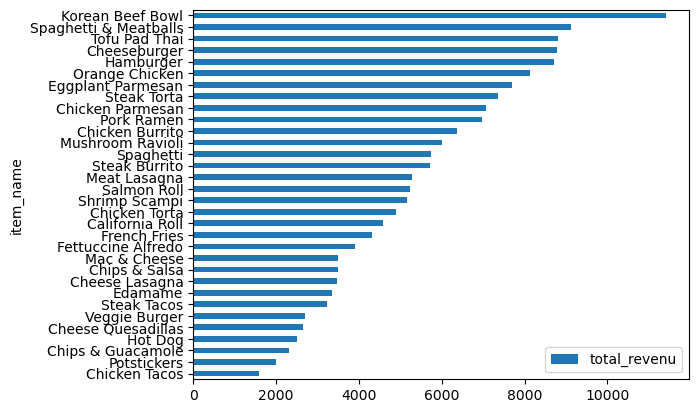

In [16]:
import matplotlib.pyplot as plt

(commande_df_correct
.groupby(["item_name"])
.agg({"total_revenu": "sum"})
.sort_values(by="total_revenu")
.plot
.barh()
)

plt.savefig("../visuals/best_item.png")

##### Si on veut analyser selon une cuisine specifique pour detecter des opportinutes pour chaque cuisine, par exemple la cuisine Italienne, on peut utiliser la fonction query() 

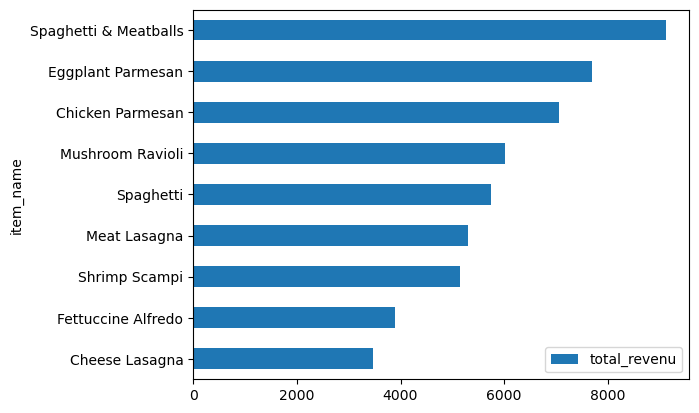

In [17]:
(commande_df_correct
.query("category=='Italian'")
.groupby(["item_name"])
.agg({"total_revenu": "sum"})
.sort_values(by="total_revenu")
.plot
.barh()
)
plt.savefig("../visuals/best_italians_items.png")

# analyse des périodes de pointe

Pour cela, nous allons faire une analyse basée sur les séries

*La premiere chose simple qu'on peu faire pour faire une analyse des periodes de pointe est de tracer un graphique linéaire (courbe de tendance) des heures de pointe (par heure, date ou mois) à partir de nos données.

**NB** Puis qu'on travaille avec les series temporaires ici, definir la colonne date comme index de notre dataframe va nous permettre d'utiliser quelques aggregation de series temporaires tres interssante*

In [78]:
commande_df_correct.head()

,order_details_id,order_id,order_date,order_time,item_id,item_name,category,price,tax,total_revenu
0,1,1,2023-01-01,2026-04-07 11:38:36,109.0,Korean Beef Bowl,Asian,17.95,1.44,19.39
1,2,2,2023-01-01,2026-04-07 11:57:40,108.0,Tofu Pad Thai,Asian,14.50,1.16,15.66
2,3,2,2023-01-01,2026-04-07 11:57:40,124.0,Spaghetti,Italian,14.50,1.16,15.66
3,4,2,2023-01-01,2026-04-07 11:57:40,117.0,Chicken Burrito,Mexican,12.95,1.04,13.99
4,5,2,2023-01-01,2026-04-07 11:57:40,129.0,Mushroom Ravioli,Italian,15.50,1.24,16.74


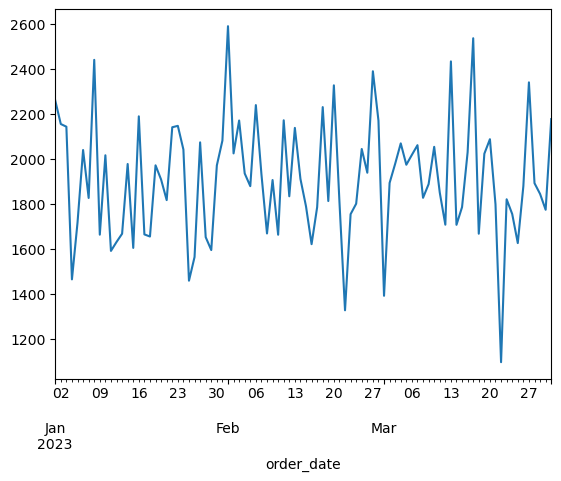

In [18]:
# Definissons la colonne order_date comme index de notre dataFrame
commande_df_correct.set_index("order_date").resample("D")["total_revenu"].sum().plot()
plt.savefig("../visuals/trend_by_day.png")

*La on a trace le graphique du chiffre d'affaire journalier pour chaque jour*

*Mais il est un peu difficile de lire ou suivre la tendance journaliere, on peu essayer avec le mois*

C:\Users\almam\AppData\Local\Temp\ipykernel_7760\648270534.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  commande_df_correct.set_index("order_date").resample("M")["total_revenu"].sum().plot()


<Axes: xlabel='order_date'>

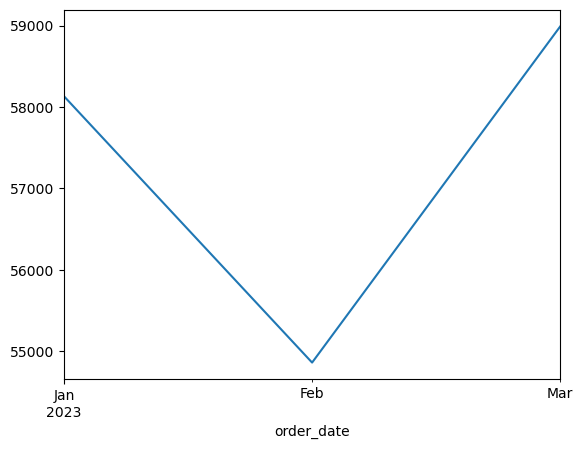

In [88]:
commande_df_correct.set_index("order_date").resample("M")["total_revenu"].sum().plot()

C:\Users\almam\AppData\Local\Temp\ipykernel_42488\3852396065.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  commande_df_correct.set_index("order_date").resample("M")["total_revenu"].sum().plot(ylim=0)


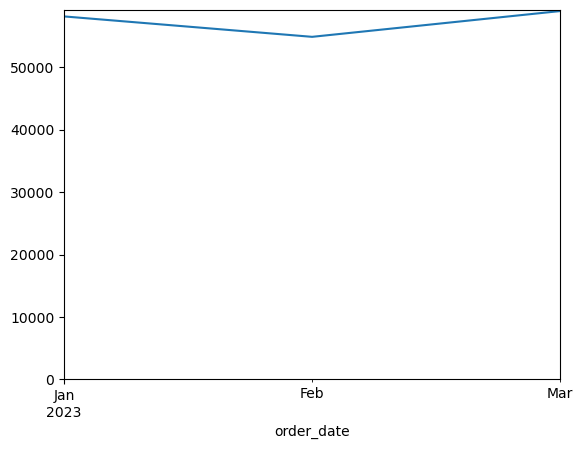

In [19]:
commande_df_correct.set_index("order_date").resample("M")["total_revenu"].sum().plot(ylim=0)
plt.savefig("../visuals/trend_by_month.png")

Nous constatons une tendance baissiere au mois de fevrier.

Mais il une meilleur manière d'analyser la saisonalité. Au lieu de faire ça on à besoin de créer deux colonnes, une pour les jours de la semaine et l'autre les heures

In [99]:
commande_df_correct["dayofweek"] = commande_df_correct.order_date.dt.dayofweek
commande_df_correct["hour"] = commande_df_correct.order_time.dt.hour
commande_df_correct.head()

,order_details_id,order_id,order_date,order_time,item_id,item_name,category,price,tax,total_revenu,dayofweek,hour
0,1,1,2023-01-01,2026-04-07 11:38:36,109.0,Korean Beef Bowl,Asian,17.95,1.44,19.39,6,11
1,2,2,2023-01-01,2026-04-07 11:57:40,108.0,Tofu Pad Thai,Asian,14.50,1.16,15.66,6,11
2,3,2,2023-01-01,2026-04-07 11:57:40,124.0,Spaghetti,Italian,14.50,1.16,15.66,6,11
3,4,2,2023-01-01,2026-04-07 11:57:40,117.0,Chicken Burrito,Mexican,12.95,1.04,13.99,6,11
4,5,2,2023-01-01,2026-04-07 11:57:40,129.0,Mushroom Ravioli,Italian,15.50,1.24,16.74,6,11


### Maintenant on est prêt à créer une table de pivot

Nous allons pivoter de telle sorte que les heures deviennent les lignes et colonnes deviennent les jours de semaine avec la somme du chiffre d'affaire par jour

In [101]:
commande_df_correct.pivot_table(
    index="hour",
    columns="dayofweek",
    values= "total_revenu",
)

dayofweek,0,1,2,3,4,5,6
hour,,,,,,,
10,NaN,NaN,NaN,12.043333,NaN,16.150000,NaN
11,13.996774,14.485156,14.301310,13.827297,13.822738,14.229684,13.932903
12,13.893725,14.217718,13.737603,14.309763,14.262403,14.449886,13.998722
13,14.461120,13.866776,14.528389,13.778772,14.599127,14.070000,14.596097
14,14.490463,14.528168,14.357857,13.812180,13.649020,14.862985,14.215796
15,14.424301,14.265680,14.335294,13.884400,14.582400,14.219024,14.086210
16,13.390362,14.614304,14.345108,15.141069,13.828438,14.391532,14.376341
17,13.586697,14.850298,13.948798,14.600100,14.246700,14.166685,14.430817
18,13.787972,14.784265,13.944583,13.731667,14.037219,13.921327,14.612471


In [102]:
commande_df_correct.pivot_table(
    index="hour",
    columns="dayofweek",
    values= "total_revenu",
    aggfunc= "sum"
)

dayofweek,0,1,2,3,4,5,6
hour,,,,,,,
10,NaN,NaN,NaN,36.13,NaN,32.30,NaN
11,1301.70,927.05,1201.31,1534.83,1161.11,1351.82,1295.76
12,4140.33,2118.44,2005.69,3620.37,4036.26,3814.77,3723.66
13,3485.13,2107.75,2164.73,3141.56,4014.76,2856.21,4524.79
14,1564.97,1903.19,2010.10,1837.02,2088.30,1991.64,2231.88
15,1341.46,1783.21,1705.90,1388.44,1458.24,1165.96,1746.69
16,1847.87,2309.06,2668.19,2407.43,2212.55,1597.46,1768.29
17,2961.90,2494.85,2552.63,2920.02,2849.34,2521.67,3001.61
18,2991.99,3015.99,2342.69,2471.70,2119.62,2728.58,2542.57


<Axes: xlabel='dayofweek', ylabel='hour'>

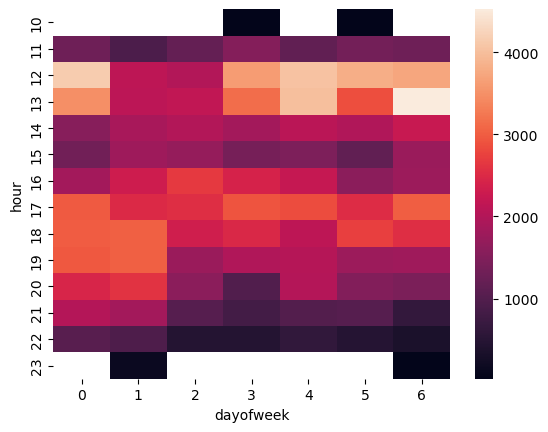

In [104]:
import seaborn as sns

sns.heatmap(
        commande_df_correct.pivot_table(
        index="hour",
        columns="dayofweek",
        values= "total_revenu",
        aggfunc= "sum"
    ),
)

<Axes: xlabel='dayofweek', ylabel='hour'>

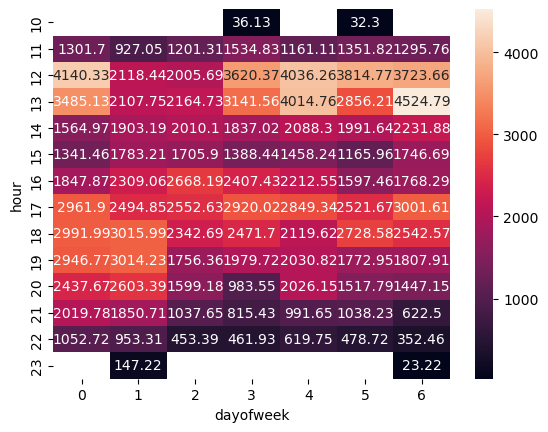

In [105]:
sns.heatmap(
        commande_df_correct.pivot_table(
        index="hour",
        columns="dayofweek",
        values= "total_revenu",
        aggfunc= "sum"
    ),
    annot=True,
    fmt= "g"
)

<Axes: xlabel='dayofweek', ylabel='hour'>

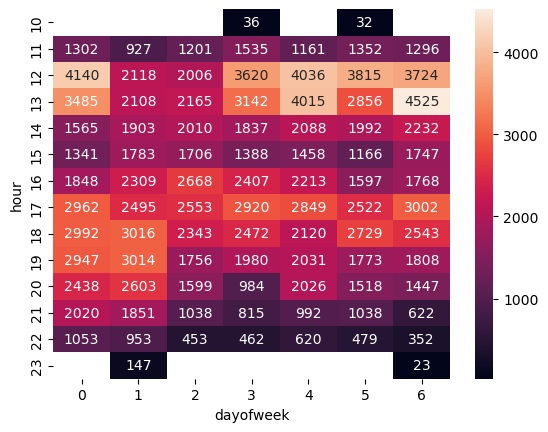

In [107]:
sns.heatmap(
        commande_df_correct.pivot_table(
        index="hour",
        columns="dayofweek",
        values= "total_revenu",
        aggfunc= "sum"
    ).round(),
    annot=True,
    fmt="g"
)

In [20]:
sns.heatmap(
        commande_df_correct.pivot_table(
        index="hour",
        columns="dayofweek",
        values= "total_revenu",
        aggfunc= "sum"
    ).round(),
    annot=True,
    fmt="g",
    cmap="vlag"
)
plt.savefig("../visuals/final_heatmap.png")

NameError: name 'sns' is not defined

Ici la couleur rouge represente la periode de la plus grande performence de vente tandis que celle du rouge represente la periode de la faible vente

Nous constatons qu'a 10h et a 23h il y'a des il presque pas de vente, cela pourrais s'expliquer par le fait que le gerant ouvre un plus tot et ferme un peu plus tard le restaurant

Par contre les heures les plus importantes de ventes du restaurant reste de 12h a 13h (Heure de dejeuner) et de 17h a 21h (heure de dinner)

la plus grande vente etait un dimanche aux heure des dejeunes

Notre map montre aussi que les heures de 22h ne sont pas occupees en soit, pres que pas CA important, au contraire il semble que nous perdons de l'argent a cette car nous employons du personnel dans un restaurant qui ne génère pas beaucoup de revenus.

On doit noter aussi qu'il est neccessaire de fermer le restaurant les dimanche a partir de 21h car il y'a quasiment pas de vente a partir de cette heure

Au final, en reduisant le menu et en optimisant les heures basees sur notre heatmap, nous pouvont faire des recommandations  interessant gerant du restaurant.